This notebook uses this [USA Airports Dataset](https://www.kaggle.com/datasets/flashgordon/usa-airport-dataset) from Kaggle.

In [1]:
import pandas as pd
import duckdb

In [2]:
con = duckdb.connect()

In [3]:
describe_query = """
DESCRIBE 'Data/Airports2.csv';
"""

In [4]:
col_names = con.execute(describe_query).df()[['column_name', 'column_type']]
col_names

,column_name,column_type
0,Origin_airport,VARCHAR
1,Destination_airport,VARCHAR
2,Origin_city,VARCHAR
3,Destination_city,VARCHAR
4,Passengers,BIGINT
5,Seats,BIGINT
6,Flights,BIGINT
7,Distance,BIGINT
8,Fly_date,DATE
9,Origin_population,BIGINT


In [5]:
total_number_flights_query = """
SELECT Origin_airport, 
COUNT() AS Count
FROM 'Data/Airports2.csv'
GROUP BY Origin_airport
ORDER BY Count Desc
"""

In [6]:
total_number_flights = con.execute(total_number_flights_query).df()
total_number_flights

,Origin_airport,Count
0,ORD,158496
1,ATL,131046
2,DFW,106698
3,DTW,99624
4,MSP,98922
...,...,...
678,S27,1
679,TBR,1
680,VWH,1
681,HLG,1


Acording to this data ORD (Chicago) is the besiest aiport in the US. Note: This is all time not year by year.

In [7]:
total_flights_all_time = """
SELECT Fly_date,
COUNT() AS Count
FROM 'Data/Airports2.csv'
GROUP BY Fly_Date
"""

In [8]:
total_flights_all_time_df = con.execute(total_flights_all_time).df()


<Axes: xlabel='Fly_date'>

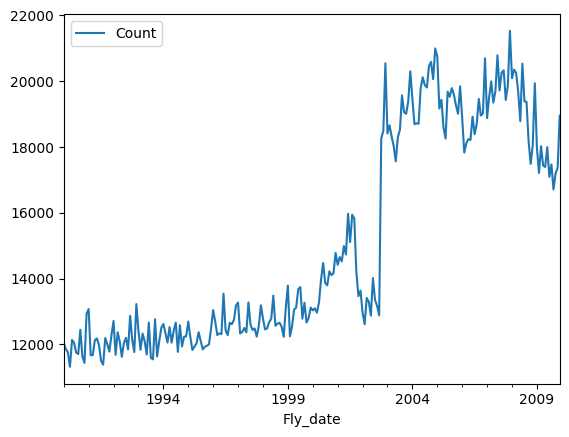

In [9]:
total_flights_all_time_df.set_index('Fly_date').sort_values(by='Fly_date').plot()

Here we can see flying inside the US started to take off in the 2000s. You can see a sharp drop where 9/11 took place, then a massive rise in 03.

In [10]:
flights_one_year = """
SELECT Fly_date,
COUNT() AS Count
FROM 'Data/Airports2.csv'
WHERE Fly_date > '2007-12-31' AND Fly_date < '2009-01-01'
GROUP BY Fly_Date
"""

In [11]:
flights_one_year_df= con.execute(flights_one_year).df().set_index('Fly_date').sort_values(by='Fly_date')


<Axes: xlabel='Fly_date'>

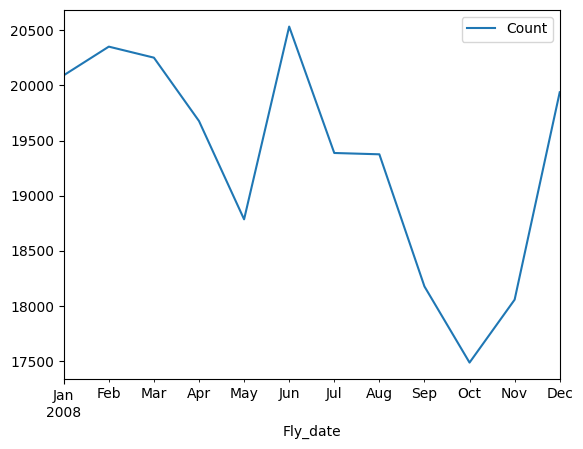

In [12]:
flights_one_year_df.plot()

Although this data is pre 2009 we can still see an influx of travel around the holidays. Mainly around the winter and summer holidays. Here we see in 2008 October a reduced amount of travel compared to other months.

---



## Reducing Scope 

I want to find 1-3 high volume routes to focus on. With these I would like to try and forcast the upcoming demand for each route. I'd also like to model the capacity of each route and see if demand is likely to become higher than the capacity.

In [13]:
print(f"From: {total_flights_all_time_df['Fly_date'].sort_values().min()} \nTo: {total_flights_all_time_df['Fly_date'].sort_values().max()}")
print(f"Number of flights: {total_number_flights['Count'].sum()}")

From: 1990-01-01 00:00:00 
To: 2009-12-01 00:00:00
Number of flights: 3606803


In [14]:
route_volume_query ="""
SELECT
    Origin_airport,
    Destination_airport,
    SUM(Passengers) AS Total_passengers
FROM 'Data/Airports2.csv'
GROUP BY
    Origin_airport,
    Destination_airport
ORDER BY
    Total_passengers DESC
LIMIT 5
"""

route_volume_df= con.execute(route_volume_query).df()


In [15]:
route_volume_df

,Origin_airport,Destination_airport,Total_passengers
0,OGG,HNL,32364612.0
1,HNL,OGG,29744742.0
2,LAX,HNL,28964154.0
3,HNL,LAX,28632161.0
4,LAS,LAX,26333721.0


These are the all time most travelled routes in our data. Lets look at how OGG (Kahului) to HNL (Honolulu) compare to the number of seats available.

In [16]:
seats_v_passengers_OGG_HNL_query ="""
SELECT
    Fly_date,
    Origin_airport,
    Destination_airport,
    SUM(Passengers) AS Total_passengers,
    SUM(Seats) AS Total_seats,
FROM 'Data/Airports2.csv'
WHERE
    Origin_airport = 'OGG'
    AND
    Destination_airport = 'HNL'
GROUP BY
    Fly_date,
    Origin_airport,
    Destination_airport,
ORDER BY Fly_date

"""

seats_v_passengers_OGG_HNL_df= con.execute(seats_v_passengers_OGG_HNL_query).df()


In [17]:
seats_v_passengers_OGG_HNL_df

,Fly_date,Origin_airport,Destination_airport,Total_passengers,Total_seats
0,1990-01-01,OGG,HNL,141012.0,225698.0
1,1990-02-01,OGG,HNL,130843.0,209287.0
2,1990-03-01,OGG,HNL,149182.0,248716.0
3,1990-04-01,OGG,HNL,139269.0,262024.0
4,1990-05-01,OGG,HNL,137610.0,264595.0
...,...,...,...,...,...
235,2009-08-01,OGG,HNL,102761.0,146594.0
236,2009-09-01,OGG,HNL,95460.0,130242.0
237,2009-10-01,OGG,HNL,90871.0,127077.0
238,2009-11-01,OGG,HNL,86661.0,111831.0


<Axes: xlabel='Fly_date'>

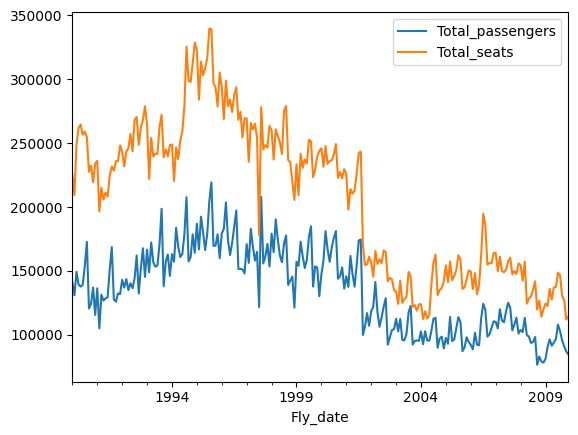

In [18]:
seats_v_passengers_OGG_HNL_df[['Fly_date', 'Total_passengers', 'Total_seats']].set_index('Fly_date').plot()

In [19]:

seats_v_passengers_OGG_HNL_df['Load'] = (seats_v_passengers_OGG_HNL_df['Total_passengers'] / seats_v_passengers_OGG_HNL_df['Total_seats'])

<Axes: xlabel='Fly_date'>

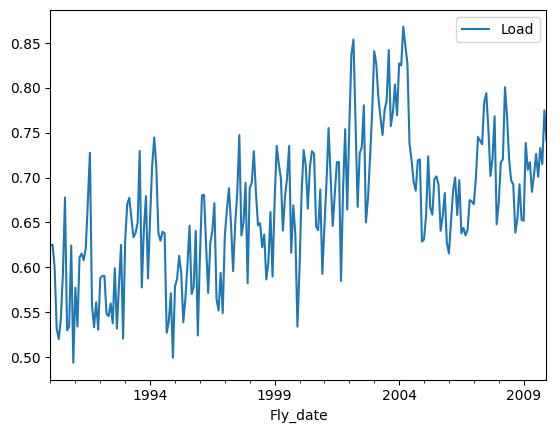

In [20]:
seats_v_passengers_OGG_HNL_df.plot(x='Fly_date', y='Load')

In [53]:
df = seats_v_passengers_OGG_HNL_df.copy()


In [54]:
window = 12  # 12 months
df['rolling_mean'] = df['Load'].rolling(window).mean()

df = df.dropna()

<Axes: xlabel='Fly_date'>

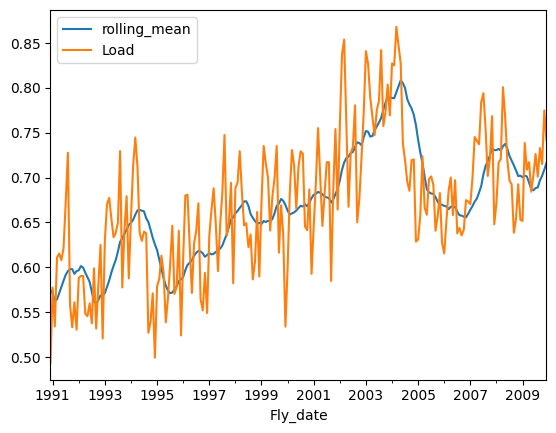

In [55]:
df.plot(x='Fly_date', y=['rolling_mean', 'Load'])